In [202]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [203]:
img = cv2.imread('Assets/Meledak.png')

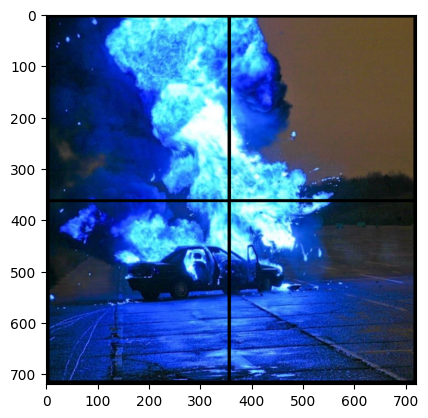

In [204]:
plt.imshow(img)

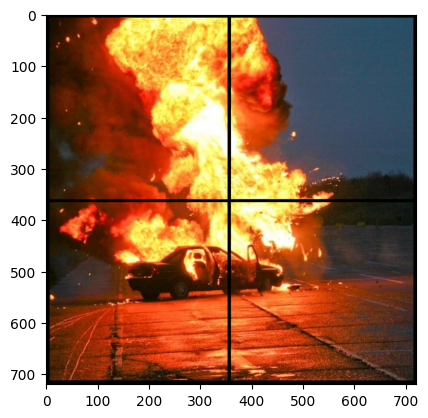

In [205]:
citra1 = plt.imread("Assets/Meledak.png")
plt.imshow(citra1)

In [206]:
def Slicing(gambar, a, b, mode='H'):
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

In [207]:
potongKiri = Slicing(citra1, 0, 349, 'V')
kiriA = Slicing(potongKiri, 0, 370, 'H')
kiriB = Slicing(potongKiri, 370, 710, 'H')

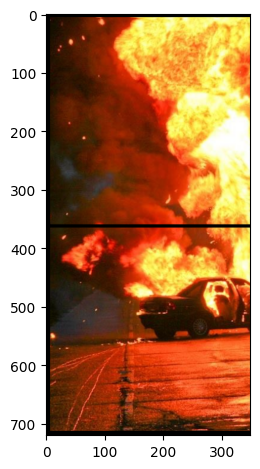

In [208]:
plt.imshow(potongKiri)
plt.tight_layout()
plt.show()

In [209]:
kananA = Slicing(potongKiri, 0, 358, 'H')
kananB = Slicing(potongKiri, 360, 705, 'H')

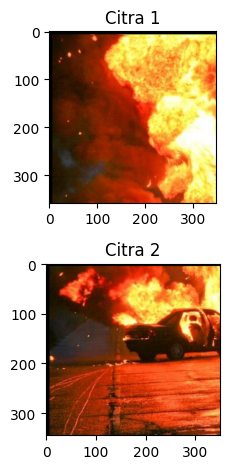

In [210]:
plt.subplot(2, 2, 1)
plt.imshow(kananA)
plt.title('Citra 1')


plt.subplot(2, 2, 3)
plt.imshow(kananB)
plt.title('Citra 2')

plt.tight_layout()
plt.show()

In [211]:
potongKanan = Slicing(citra1, 358, 705, 'V')
kiriA = Slicing(potongKanan, 0, 350, 'H')
kiriB = Slicing(potongKanan, 360, 705, 'H')

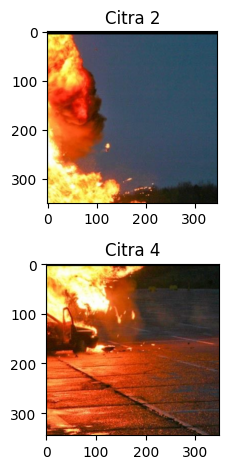

In [212]:
plt.subplot(2, 2, 2)
plt.imshow(kiriA)
plt.title('Citra 2')
plt.subplot(2, 2, 4)
plt.imshow(kiriB)
plt.title('Citra 4')
plt.tight_layout()
plt.show()

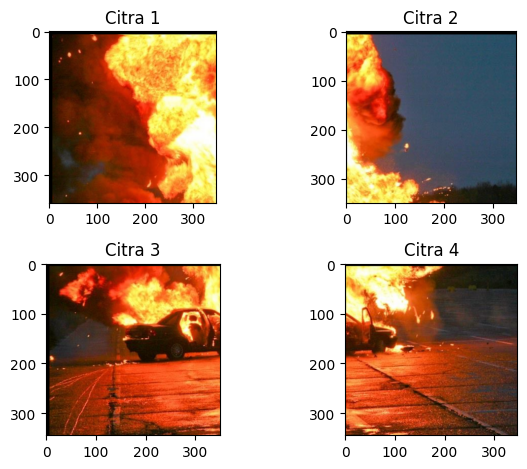

In [213]:
plt.subplot(2, 2, 1)
plt.imshow(kananA)
plt.title('Citra 1')
plt.subplot(2, 2, 2)
plt.imshow(kiriA)
plt.title('Citra 2')
plt.subplot(2, 2, 3)
plt.imshow(kananB)
plt.title('Citra 3')
plt.subplot(2, 2, 4)
plt.imshow(kiriB)
plt.title('Citra 4')
plt.tight_layout()
plt.show()

In [214]:
def merge_image(citra1, citra2, orientation='H'):
    if orientation == 'H':
        tinggi = max(citra1.shape[0], citra2.shape[0])
        lebar_total = citra1.shape[1] + citra2.shape[1]
        if len(citra1.shape) == 2:
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype)        
        else:    
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype)
        
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2
    else:
        tinggi_total = citra1.shape[0] + citra2.shape[0]
        lebar = max(citra1.shape[1], citra2.shape[1])
        if len(citra1.shape) == 2:
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype)
        else:
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype)
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2
    return gabungan

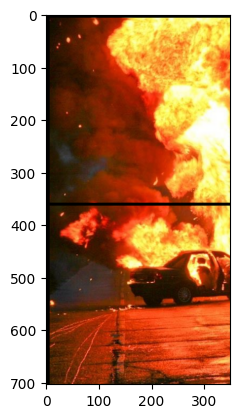

In [215]:
merge13 = merge_image(kananA, kananB, orientation='V')
plt.imshow(merge13)

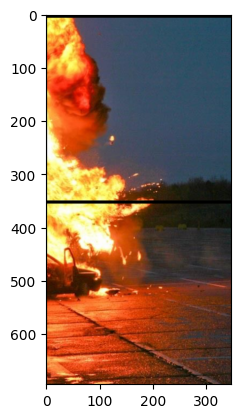

In [216]:
merge24 = merge_image(kiriA, kiriB, orientation='V')
plt.imshow(merge24)

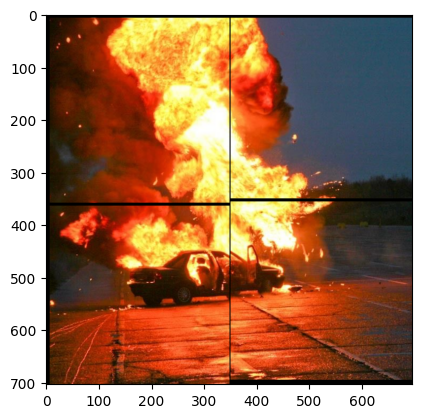

In [217]:
merge1234 = merge_image(merge13, merge24, orientation='H')
plt.imshow(merge1234)

(703, 696)


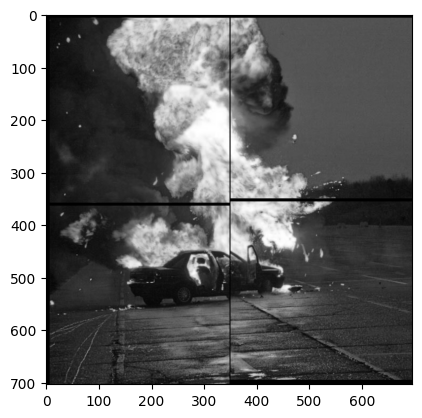

In [218]:
gambar = cv2.cvtColor(merge1234, cv2 .COLOR_BGR2GRAY)
plt.imshow(gambar, cmap = 'gray')
print(gambar.shape)

In [219]:
def ekualisasi (input_gambar):
    intensitas = np.zeros(256, dtype=int) 
    tinggi, lebar = input_gambar.shape 
    for i in range(tinggi): 
        for j in range(lebar): 
            bantu = input_gambar[i,j] 
            intensitas[bantu] += 1 

    cdf = np.zeros(256, dtype=int) 
    for i in range(256): 
        cdf[i] = np.sum(intensitas[0:i+1]) 

    hasil = np.round((cdf*255)/(tinggi*lebar)) 
    return hasil

In [220]:
def ambil_gambar_ekualisasi(input_gambar):
    height, width = input_gambar.shape
    hasil_ekualisasi = ekualisasi(input_gambar)
    hasil = np.zeros(input_gambar.shape, dtype=int) 
    
    for i in range(height): 
        for j in range(width): 
            bantu = input_gambar[i,j] 
            hasil[i,j] = hasil_ekualisasi [bantu]

    return hasil

In [225]:
def histogram(image):
    tinggi, lebar = image.shape
    sumValue = np.zeros(256).astype(float)
    
    for i in range(tinggi):
        for j in range(lebar):
            bantu = image[i, j]
            sumValue[bantu] += 1

    value = [i for i in range(0, 256)]
    plt.bar(value, sumValue)

In [226]:
ekualisasiGambar = ambil_gambar_ekualisasi(gambar)
plt.figure(figsize=(15, 15))
plt.subplot(1, 2, 1)
plt.imshow(gambar,  cmap='gray')
plt.title("sebelum ekualisasi")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(ekualisasiGambar,  cmap='gray')
plt.title("setelah ekualisasi")
plt.axis('off')

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

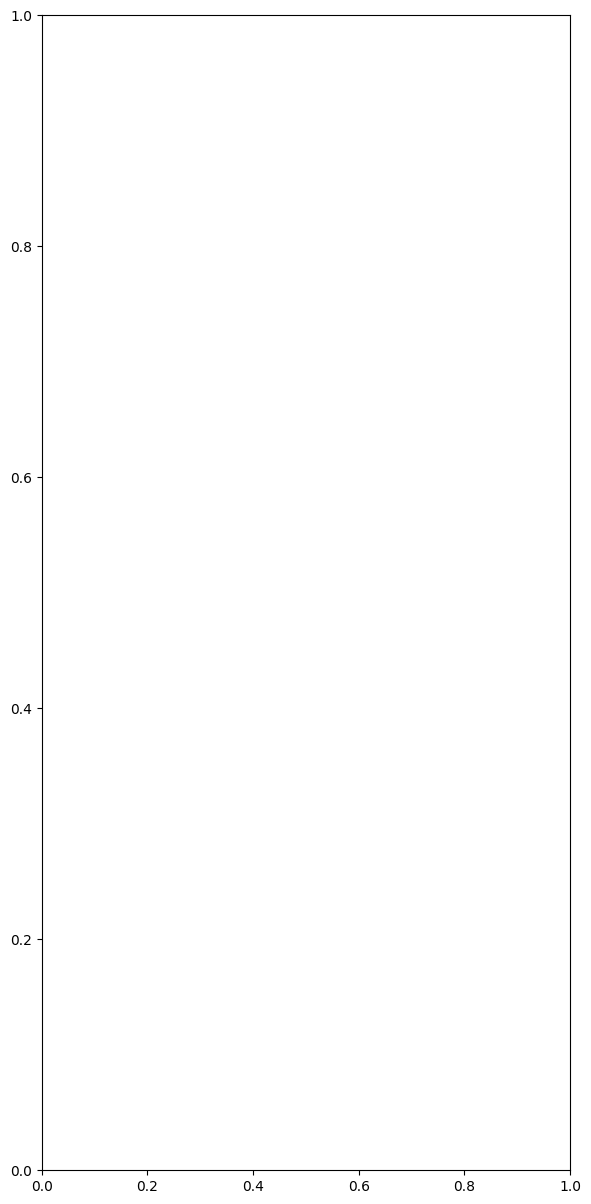

In [228]:
plt.figure(figsize=(15, 15))
plt.subplot(1, 2, 1)
histogram(gambar)
plt.title("sebelum ekualisasi")

plt.subplot(1, 2, 2)
histogram(ekualisasiGambar)
plt.title("setelah ekualisasi")